<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2025/blob/main/78_C_DOE_DBCA_Ejemplo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño de Experimentos 2025**
## **TEMA 1: Diseños en Bloques Completamente aleatorizados DBCA**



<a name="inicio"></a>


## **1.** [Librerias básicas](#T1)
## **2.** [Ejemplo de un Diseños en Bloques Completos al Azar - DBCA](#T2)

## **3.** [El DataFrame de los datos](#T3)

## **4.** [Analisis descriptivo de la variable](#T4)

## **5.** [Acediendo a algunos atributos del DataFrame](#T5)

## **6.** [BoxPlot para DBCA](#T6)

## **7.** [Análisis de Varianza - Anova](#T7)


## **8.** [Comparaciones Múltiples](#T8)

## **9.** [Supuesto del Modelo - Normalidad](#T9)


## **10.** [Homocedasticidad](#T10)

## **11.** [](#T11)

## **12.** [](#T12)

## **13.** [](#T13)

## **14.** [](#T14)

## **15.** [](#T15)

## **16.** [](#T16)

## **17.** [](#T17)


## **18.** [](#T18)

## **19.** [](#T19)


## **20.** [](#T20)

## **21.** [](#T21)

## **22.** [](#T22)

## **23.** [](#T23)

## **24.** [](#T24)

## **25.** [](#T25)

## **26.** [](#T26)

## **27.** [](#T27)


## **28.** [](#T28)

## **29.** [](#T29)


## **30.** [](#T30)

## **31.** [](#T31)


[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Librerías Básicas**

In [1]:
# @title **Librerias de Python**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import scipy.stats as stats


[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. Ejemplo de un Diseños en Bloques Completos al Azar - DBCA**

# **Ejemplo de un Diseños en Bloques Completos al Azar - DBCA**

### **2.1 Problema de Aplicación.** _Se evalúa la eficacia de sulfato ferroso a 4 diferentes concentraciones $2$, $2.5$, $3$, y $4$ $mg/kg/día$ para combatir la anemia en personas con desnutrición. Dada la variabilidad de pesos y sexos, se decidió agrupar en bloque de personas por pesos lo más semejantes posibles. Se les dio el tratamiento durante 4 meses y se procedió a determinar su volumen sanguíneo dando los siguientes resultados:_

|Pesos\Tratamientos|T1 |T2| T3| T4| Total ($Y_{.j}$)|
|:--:|:--:|:--:|:--:|:--:|:--:|
|B1 |4.1| 6.5| 4.1| 4.9| 19.6|
|B2 |4.1| 5.3| 4.0| 6.2| 19.6|
|B3 |6.5| 6.9| 4.5| 4.8| 22.7|
|B4 |4.3| 6.8| 4.3| 4.2| 19.6|
|B5 |6.0| 6.5| 4.1| 6.9| 23.5|
|Total Tratamiento ($Y_i.$)| 25| 32| 21| 27| 105|

- **Las hipótesis a probar: Para los tratamientos**
  - _Volumen sanguíneo medio es el mismo en las diferentes concentraciones de sulfato ferroso_
$$H_{01}: \mu_{T_1}=\mu_{T_2}=\mu_{T_3}=\mu_{T_4}$$ $$Vs$$ $$H_{a1}: \mu_{T_i}\neq\mu_{T_j}$$ _Al menos un tratamiento es diferente_

- **Las hipótesis a probar: Para los Bloques**

  - _Volumen sanguíneo medio es el mismo en las diferentes pesos de los grupos_

$$H_{02}: \mu_{B_1}=\mu_{B_2}=\mu_{B_3}=\mu_{B_4}=\mu_{B_4}$$ $$Vs$$ $$H_{a2}: \mu_{B_i}\neq\mu_{B_j}$$  _Al menos un bloque (pesos) es
diferente_

[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. El DataFrame de los datos**

In [3]:
#@title **El DataFrame de los datos**
Pesos = (['B1']*4+['B2']*4+['B3']*4+['B4']*4+['B5']*4)*1
S_Ferroso = (['T1']*1+['T2']*1+['T3']*1+['T4']*1)*5
V_Sanguineo =[4.1, 6.5, 4.1, 4.9,  4.1, 5.3, 4.0, 6.2,  6.5, 6.9, 4.5, 4.8, 4.3, 6.8, 4.3, 4.2,  6.0, 6.5, 4.1, 6.9]
dic_DBCA ={'Pesos': Pesos,'S_Ferroso': S_Ferroso, 'V_Sanguineo':V_Sanguineo}

DBCA  = pd.DataFrame(dic_DBCA)
DBCA

,Pesos,S_Ferroso,V_Sanguineo
0,B1,T1,4.1
1,B1,T2,6.5
2,B1,T3,4.1
3,B1,T4,4.9
4,B2,T1,4.1
5,B2,T2,5.3
6,B2,T3,4.0
7,B2,T4,6.2
8,B3,T1,6.5
9,B3,T2,6.9


[⬆️ Volver al inicio](#inicio)

[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. Analisis descriptivo de la variable**

In [4]:
# **Analisis descriptivo de la variable**
DBCA.describe()


,V_Sanguineo
count,20.000000
mean,5.250000
std,1.139021
min,4.000000
25%,4.175000
50%,4.850000
75%,6.500000
max,6.900000


[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. Acediendo a algunos atributos del DataFrame**

In [7]:
#@title **a Nombre de las columnas**
DBCA.columns

Index(['Pesos', 'S_Ferroso', 'V_Sanguineo'], dtype='object')

In [6]:
#@title **b Tipo de variables**
DBCA.dtypes

,0
Pesos,object
S_Ferroso,object
V_Sanguineo,float64


In [8]:
#@title **c. Contar las observaciones de una de las variables**
DBCA["Pesos"].value_counts()

,count
Pesos,
B1,4
B2,4
B3,4
B4,4
B5,4


In [9]:
#@title **d. Contar las observaciones**
DBCA["S_Ferroso"].value_counts()

,count
S_Ferroso,
T1,5
T2,5
T3,5
T4,5


In [10]:
#@title **e. Contar las observaciones**
DBCA["V_Sanguineo"].value_counts()

,count
V_Sanguineo,
4.1,4
6.5,3
6.9,2
4.3,2
4.9,1
4.0,1
5.3,1
4.5,1
6.2,1


In [12]:
#@title **f. Contar las observaciones**
DBCA[["S_Ferroso","V_Sanguineo"]].describe()

,V_Sanguineo
count,20.000000
mean,5.250000
std,1.139021
min,4.000000
25%,4.175000
50%,4.850000
75%,6.500000
max,6.900000


In [13]:
#@title **g. Contar las observaciones**
DBCA[["Pesos",'V_Sanguineo']].T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
Pesos,B1,B1,B1,B1,B2,B2,B2,B2,B3,B3,B3,B3,B4,B4,B4,B4,B5,B5,B5,B5
V_Sanguineo,4.1,6.5,4.1,4.9,4.1,5.3,4.0,6.2,6.5,6.9,4.5,4.8,4.3,6.8,4.3,4.2,6.0,6.5,4.1,6.9


[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. BoxPlot para DBCA**

<Axes: title={'center': 'V_Sanguineo vs S_Ferroso'}, xlabel='S_Ferroso', ylabel='V_Sanguineo'>

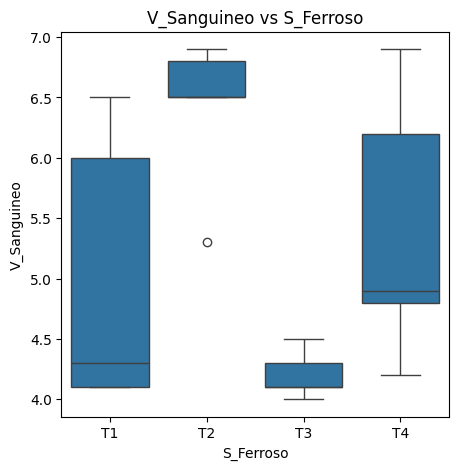

In [15]:
#@title **A. BoxPlot para DBCA: V_Sanguineo vs S_Ferroso**
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_title('V_Sanguineo vs S_Ferroso')
sns.boxplot(x="S_Ferroso", y='V_Sanguineo',data=DBCA,ax=ax)


<Axes: title={'center': 'V_Sanguineo vs Pesos'}, xlabel='Pesos', ylabel='V_Sanguineo'>

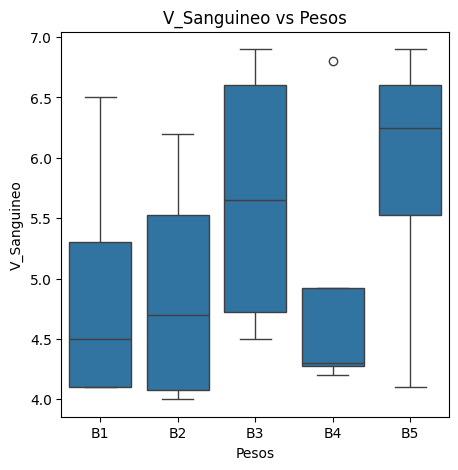

In [16]:
#@title **B. BoxPlot para DBCA: V_Sanguineo vs Pesos**
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_title('V_Sanguineo vs Pesos')
sns.boxplot(x="Pesos", y='V_Sanguineo',data=DBCA,ax=ax)


/tmp/ipython-input-4254682319.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="S_Ferroso", y='V_Sanguineo', data=DBCA, ax=axes[0], palette='viridis')
/tmp/ipython-input-4254682319.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pesos", y='V_Sanguineo', data=DBCA, ax=axes[1], palette='plasma')


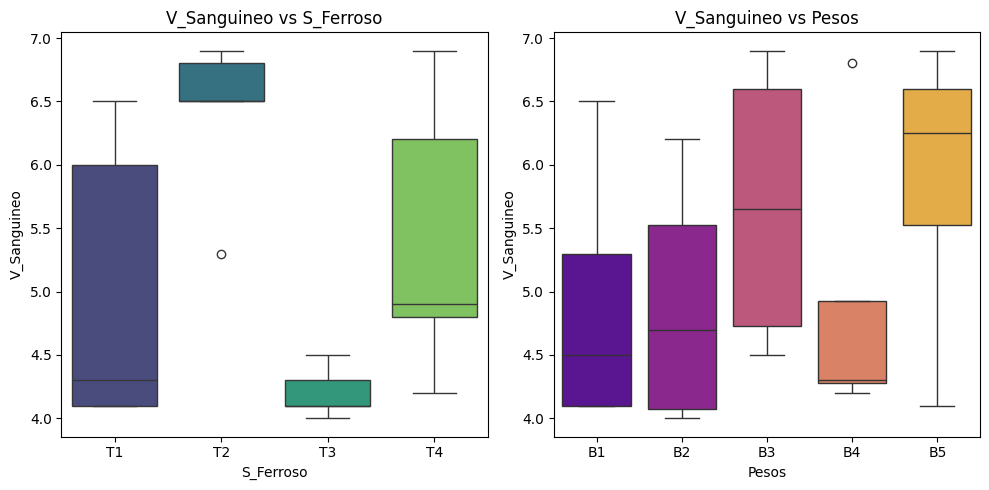

In [18]:
# @title **C. Boxplot en un solo plano con colores diversos**
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(x="S_Ferroso", y='V_Sanguineo', data=DBCA, ax=axes[0], palette='viridis')
axes[0].set_title('V_Sanguineo vs S_Ferroso')

sns.boxplot(x="Pesos", y='V_Sanguineo', data=DBCA, ax=axes[1], palette='plasma')
axes[1].set_title('V_Sanguineo vs Pesos')

plt.tight_layout()
plt.show()

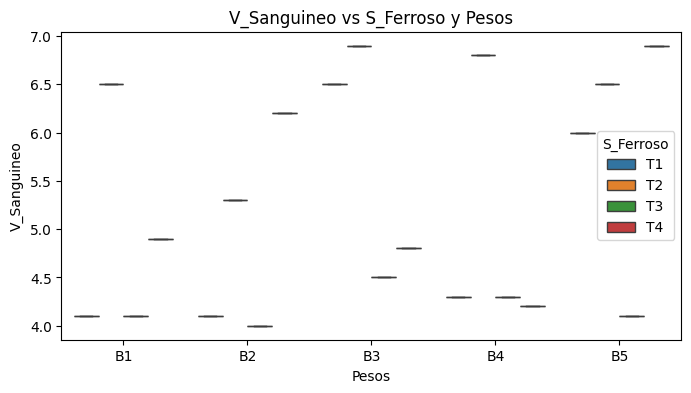

In [20]:
# @title **D. Diagrama Bivariado no es sposible dado que no hay replicas**
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.set_title('V_Sanguineo vs S_Ferroso y Pesos')
sns.boxplot(x="Pesos", y="V_Sanguineo", hue='S_Ferroso', data=DBCA, ax=ax);

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. Análisis de Varianza - Anova**

In [34]:
#@title **A. Análisis de Varianza Tipo I**
modeloDBCA = ols("V_Sanguineo ~ S_Ferroso + Pesos", data = DBCA).fit()
anova_result2 = sm.stats.anova_lm(modeloDBCA, typ=1)
print (anova_result2)

             df  sum_sq   mean_sq         F    PR(>F)
S_Ferroso   3.0  12.550  4.183333  6.015578  0.009644
Pesos       4.0   3.755  0.938750  1.349910  0.307973
Residual   12.0   8.345  0.695417       NaN       NaN


In [35]:
anova_result2.T

,S_Ferroso,Pesos,Residual
df,3.000000,4.000000,12.000000
sum_sq,12.550000,3.755000,8.345000
mean_sq,4.183333,0.938750,0.695417
F,6.015578,1.349910,NaN
PR(>F),0.009644,0.307973,NaN


In [36]:
print(modeloDBCA.summary())

                            OLS Regression Results                            
Dep. Variable:            V_Sanguineo   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.464
Method:                 Least Squares   F-statistic:                     3.349
Date:                Sat, 06 Sep 2025   Prob (F-statistic):             0.0321
Time:                        19:25:17   Log-Likelihood:                -19.638
No. Observations:                  20   AIC:                             55.28
Df Residuals:                      12   BIC:                             63.24
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.6500      0.527     

[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. Comparaciones Múltiples**

group1,group2,meandiff,p-adj,lower,upper,reject
T1,T2,1.4,0.0903,-0.1736,2.9736,False
T1,T3,-0.8,0.4858,-2.3736,0.7736,False
T1,T4,0.4,0.8848,-1.1736,1.9736,False
T2,T3,-2.2,0.0051,-3.7736,-0.6264,True
T2,T4,-1.0,0.3011,-2.5736,0.5736,False
T3,T4,1.2,0.1705,-0.3736,2.7736,False


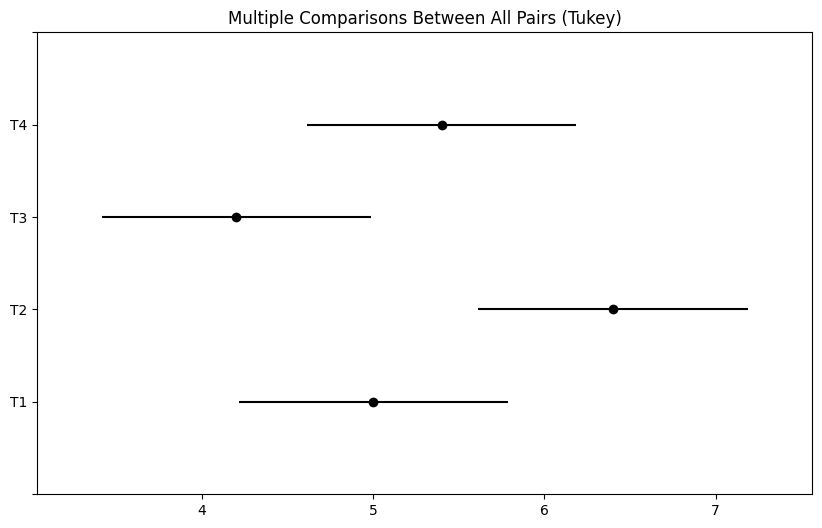

In [37]:

# @title **A. Comparaciones Múltiples S_Ferroso - Para el Factor**
tukey = pairwise_tukeyhsd(endog=DBCA["V_Sanguineo"],     # Data
                          groups=DBCA["S_Ferroso"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
#plt.vlines(x=200,ymin=-0.5,ymax=14.5, color="red")
tukey.summary()

In [39]:
# @title **B. Gráficos Comparaciones Múltiples - Pesos $\alpha=0.05$**

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=DBCA['V_Sanguineo'], groups=DBCA['S_Ferroso'], alpha=0.05)

# Print the results
print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    T1     T2      1.4 0.0903 -0.1736  2.9736  False
    T1     T3     -0.8 0.4858 -2.3736  0.7736  False
    T1     T4      0.4 0.8848 -1.1736  1.9736  False
    T2     T3     -2.2 0.0051 -3.7736 -0.6264   True
    T2     T4     -1.0 0.3011 -2.5736  0.5736  False
    T3     T4      1.2 0.1705 -0.3736  2.7736  False
----------------------------------------------------


In [38]:
# @title **C. Comparaciones Múltiples - Para Bolques: Pesos $\alpha=0.05$**

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=DBCA['V_Sanguineo'], groups=DBCA['Pesos'], alpha=0.05)

# Print the results
print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    B1     B2     -0.0    1.0 -2.5771 2.5771  False
    B1     B3    0.775 0.8814 -1.8021 3.3521  False
    B1     B4     -0.0    1.0 -2.5771 2.5771  False
    B1     B5    0.975 0.7686 -1.6021 3.5521  False
    B2     B3    0.775 0.8814 -1.8021 3.3521  False
    B2     B4      0.0    1.0 -2.5771 2.5771  False
    B2     B5    0.975 0.7686 -1.6021 3.5521  False
    B3     B4   -0.775 0.8814 -3.3521 1.8021  False
    B3     B5      0.2 0.9992 -2.3771 2.7771  False
    B4     B5    0.975 0.7686 -1.6021 3.5521  False
---------------------------------------------------


group1,group2,meandiff,p-adj,lower,upper,reject
B1,B2,-0.0,1.0,-2.5771,2.5771,False
B1,B3,0.775,0.8814,-1.8021,3.3521,False
B1,B4,-0.0,1.0,-2.5771,2.5771,False
B1,B5,0.975,0.7686,-1.6021,3.5521,False
B2,B3,0.775,0.8814,-1.8021,3.3521,False
B2,B4,0.0,1.0,-2.5771,2.5771,False
B2,B5,0.975,0.7686,-1.6021,3.5521,False
B3,B4,-0.775,0.8814,-3.3521,1.8021,False
B3,B5,0.2,0.9992,-2.3771,2.7771,False
B4,B5,0.975,0.7686,-1.6021,3.5521,False


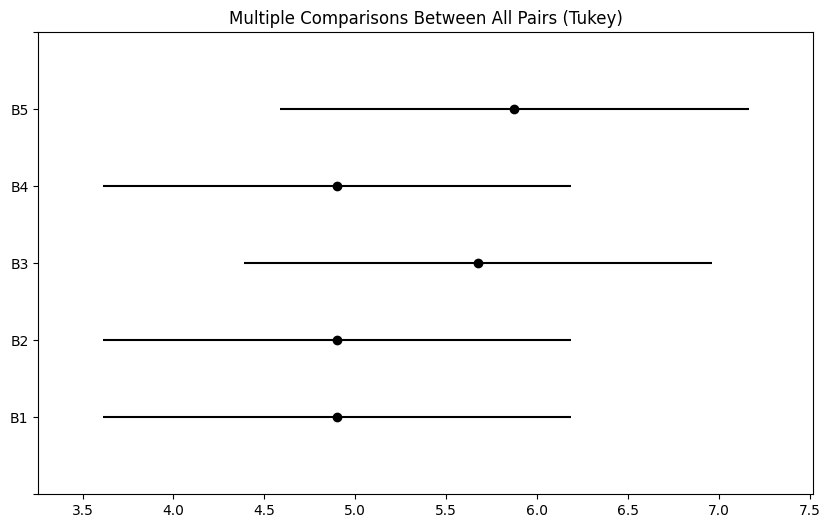

In [41]:

# @title **D.  Comparaciones Múltiples:Pesos**
tukey = pairwise_tukeyhsd(endog=DBCA["V_Sanguineo"],     # Data
                          groups=DBCA["Pesos"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
#plt.vlines(x=200,ymin=-0.5,ymax=14.5, color="red")
tukey.summary()

[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. Supuesto del Modelo - Normalidad**

In [45]:

# @title **A. Normalidad Prueba de  Shapiro Wilks**
w, pvalue = stats.shapiro(modeloDBCA.resid)


print(f"W statistic: {w:.4f}")
print(f"p-value: {pvalue:.4f}")

W statistic: 0.9553
p-value: 0.4545


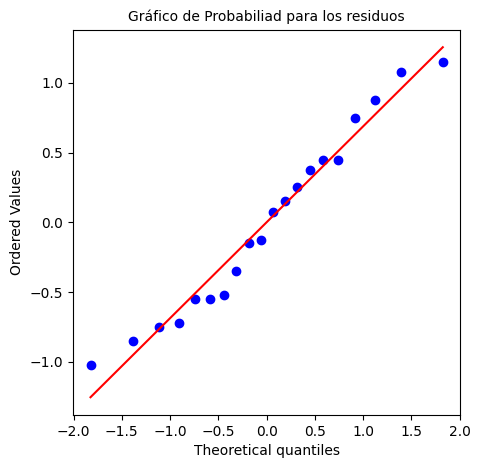

In [46]:
# @title **B. Prueba gráfica con el gráfico de probabilidad Normal y el Histograma**
fig = plt.figure(figsize= (5, 5))
ax = fig.add_subplot(111)
normality_plot, stat = stats.probplot(modeloDBCA.resid, plot= plt, rvalue= False)
ax.set_title("Gráfico de Probabiliad para los residuos", fontsize= 10)
ax.set

plt.show()

In [47]:
# @title **C. Residuos del Modelo**
modeloDBCA.resid.describe()

,0
count,2.000000e+01
mean,6.217249e-16
std,6.627296e-01
min,-1.025000e+00
25%,-5.500000e-01
50%,-2.500000e-02
75%,4.500000e-01
max,1.150000e+00


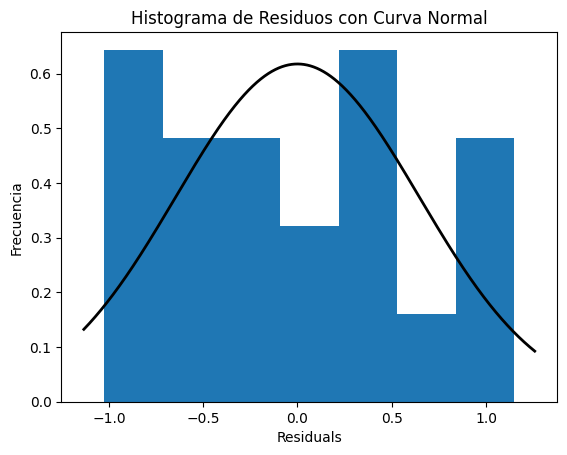

In [53]:
# @title **D. Histograma de Residuos con curva normal teórica**
plt.hist(modeloDBCA.resid, bins=7, histtype='bar', ec='k', density=True)

# Calculate mean and standard deviation for the theoretical normal curve
mu, sigma = stats.norm.fit(modeloDBCA.resid)

# Create the theoretical normal curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 10000)
p = stats.norm.pdf(x, mu, sigma)

# Plot the theoretical normal curve
plt.plot(x, p, 'k', linewidth=2)

plt.xlabel("Residuals")
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuos con Curva Normal')
plt.show()

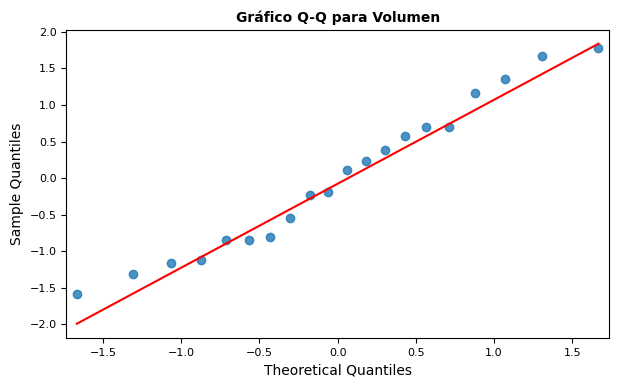

In [56]:
# @title **E. Gráfico Q-Q**
# ==============================================================================
fig, ax = plt.subplots(figsize=(7,4))
sm.qqplot(
    Volumen,
    fit   = True,
    line  = 'q',
    alpha = 0.8,
    lw    = 5,
    ax    = ax
)
ax.set_title('Gráfico Q-Q para Volumen', fontsize = 10,
             fontweight = "bold")
ax.tick_params(labelsize = 8)

[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. Homocedasticidad**

In [70]:
# @title **A. Homocedasticidad de los residuos: Usando la prueba de Levene**
L = stats.levene(DBCA['V_Sanguineo'][DBCA['S_Ferroso'] == 'T1'],
             DBCA['V_Sanguineo'][DBCA['S_Ferroso'] == 'T2'],
             DBCA['V_Sanguineo'][DBCA['S_Ferroso'] == 'T3'],
             DBCA['V_Sanguineo'][DBCA['S_Ferroso'] == 'T4'])
print("Estadístico de Levene: ", np.round(L.statistic,4))
print("Valor p: ", np.round(L.pvalue,4))

Estadístico de Levene:  1.217
Valor p:  0.3357


In [63]:
# @title **B. Homocedasticidad de los residuos: Usando la prueba de Levene**
tratamientos = DBCA['S_Ferroso'].unique()
grupos = [DBCA.loc[DBCA['S_Ferroso'] == trt, 'V_Sanguineo'] for trt in sorted(tratamientos)]

resultado_levene = stats.levene(*grupos)

# Interpretación
print("="*60)
print("PRUEBA DE LEVENE PARA HOMOCEDASTICIDAD")
print("="*60)
print(f"Estadístico de Levene: {resultado_levene.statistic:.4f}")
print(f"Valor p: {resultado_levene.pvalue:.4f}")

if resultado_levene.pvalue > 0.05:
    print("✓ No se rechaza H0: Las varianzas son homogéneas (p > 0.05)")
else:
    print("✗ Se rechaza H0: Las varianzas NO son homogéneas (p ≤ 0.05)")
print("="*60)

PRUEBA DE LEVENE PARA HOMOCEDASTICIDAD
Estadístico de Levene: 1.2170
Valor p: 0.3357
✓ No se rechaza H0: Las varianzas son homogéneas (p > 0.05)


[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. Independencia - _`durbin_watson`  y `Ljung-Box`_**

ANÁLISIS DE INDEPENDENCIA DE LOS RESIDUOS
Estadístico de Durbin-Watson: 1.6084
✓ No hay evidencia de autocorrelación (los residuos son independientes)
----------------------------------------


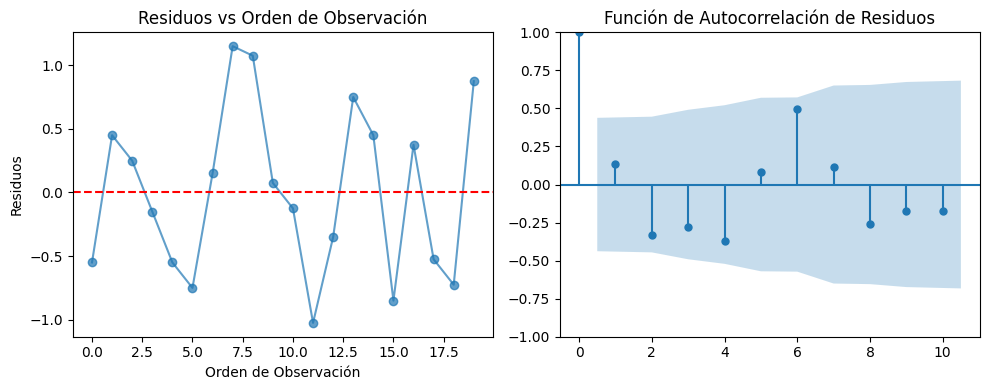


Prueba de Ljung-Box (lag 5): p-value = 0.1020
✓ No se rechaza H0: No hay autocorrelación (residuos independientes)


In [72]:
# @title **B. Supuesto de Independencia de los residuos**

print("="*60)
print("ANÁLISIS DE INDEPENDENCIA DE LOS RESIDUOS")
print("="*60)

# 1. Prueba de Durbin-Watson (para autocorrelación)
from statsmodels.stats.stattools import durbin_watson

# Asumiendo que tienes un modelo ANOVA ya ajustado
# Si no, primero ajusta el modelo:
from statsmodels.formula.api import ols

modelo = ols('V_Sanguineo ~ S_Ferroso + Pesos', data=DBCA).fit()
residuos = modelo.resid

# Prueba de Durbin-Watson
dw_test = durbin_watson(residuos)
print(f"Estadístico de Durbin-Watson: {dw_test:.4f}")

# Interpretación
if 1.5 < dw_test < 2.5:
    print("✓ No hay evidencia de autocorrelación (los residuos son independientes)")
elif dw_test <= 1.5:
    print("✗ Positiva autocorrelación detectada (los residuos no son independientes)")
else:
    print("✗ Negativa autocorrelación detectada (los residuos no son independientes)")

print("-"*40)

# 2. Gráfico de residuos vs orden de observación
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(residuos, 'o-', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs Orden de Observación')
plt.xlabel('Orden de Observación')
plt.ylabel('Residuos')

# 3. Gráfico de autocorrelación
plt.subplot(1, 2, 2)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos, lags=10, alpha=0.05, ax=plt.gca())
plt.title('Función de Autocorrelación de Residuos')

plt.tight_layout()
plt.show()

# 4. Prueba de Ljung-Box (opcional)
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuos, lags=[5], return_df=True)
print(f"\nPrueba de Ljung-Box (lag 5): p-value = {lb_test['lb_pvalue'].values[0]:.4f}")

if lb_test['lb_pvalue'].values[0] > 0.05:
    print("✓ No se rechaza H0: No hay autocorrelación (residuos independientes)")
else:
    print("✗ Se rechaza H0: Hay autocorrelación (residuos no independientes)")

print("="*60)

[⬆️ Volver al inicio](#inicio)